In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
df = pd.read_csv("rock_density_xray.csv")

In [3]:
df

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374
...,...,...
295,0.700227,2.112965
296,58.586585,2.000293
297,54.674548,1.879181
298,15.162434,2.644990


In [4]:
df.columns = ["Signal", "Density"]

In [5]:
X = df["Signal"].values.reshape(-1, 1)
y = df["Density"]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.ensemble import AdaBoostRegressor

In [9]:
ada_model= AdaBoostRegressor()

In [10]:
ada_model.fit(X_train, y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [11]:
y_pred_ada= ada_model.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
mean_squared_error(y_pred_ada, y_test)

0.021287170114531226

In [14]:
mean_squared_error(y_pred_ada, y_test)**0.5

0.14590123410900685

In [15]:
mean_absolute_error(y_pred_ada, y_test)

0.12571249552547498

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


In [17]:
pipeline = Pipeline([
    ('ada', AdaBoostRegressor())])

In [18]:
param_grid = {'ada__n_estimators':[1,20,30,40,50]}

In [19]:
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)

In [20]:
def run_model(model,X_train,y_train,X_test,y_test):
    
    # Fit Model
    model.fit(X_train,y_train)
    
    # Get Metrics
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    print(f'RMSE : {rmse}')
    
    # Plot results
    signal_range = np.arange(0,100)
    output = model.predict(signal_range.reshape(-1,1))
    
    
    plt.figure(figsize=(12,6),dpi=150)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')
    plt.plot(signal_range,output)


RMSE : 0.14225699582734255


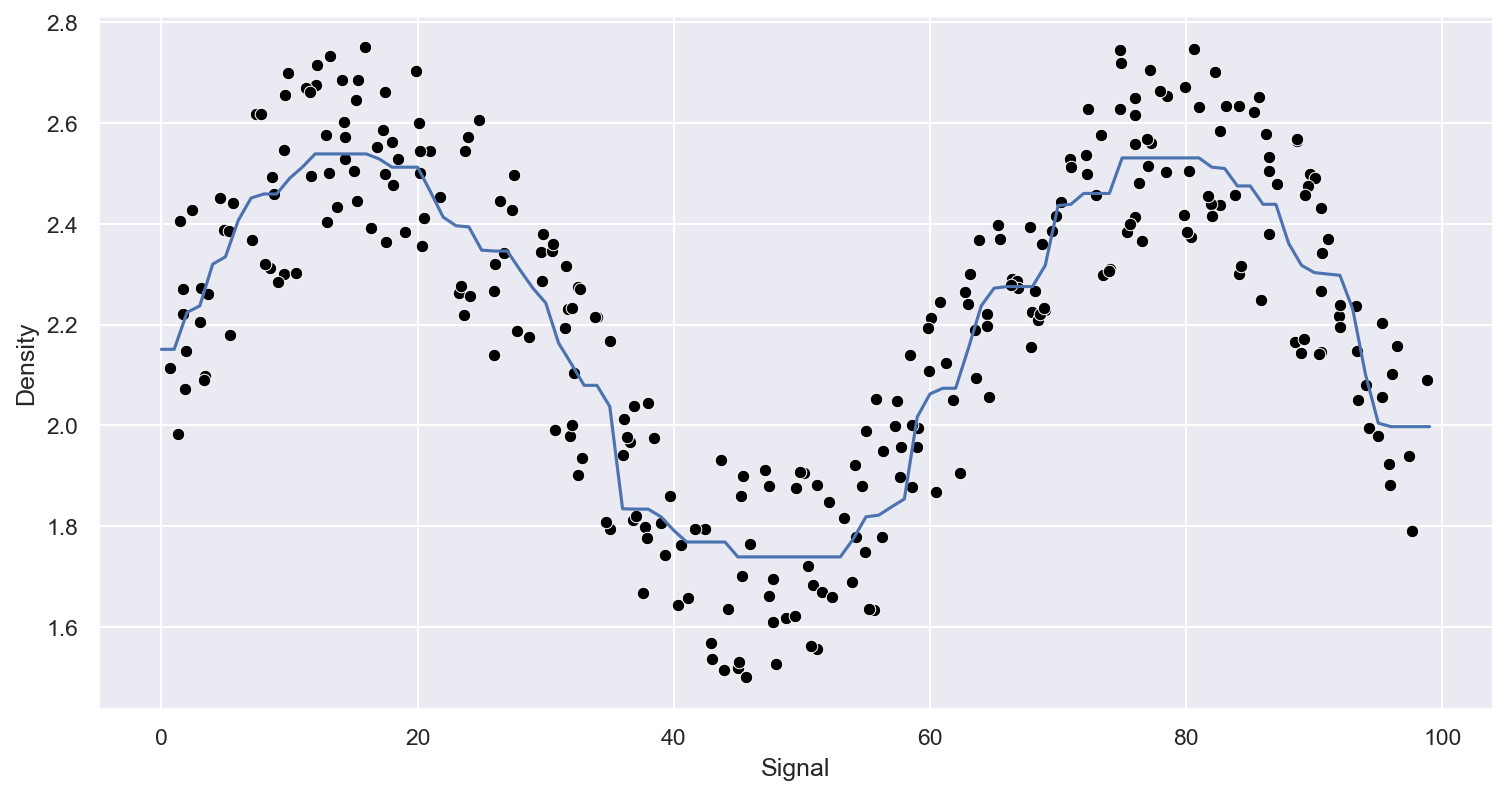

In [21]:
run_model(grid,X_train, y_train, X_test, y_test)

In [22]:
from sklearn.neighbors import KNeighborsRegressor

RMSE : 0.14069125497404916


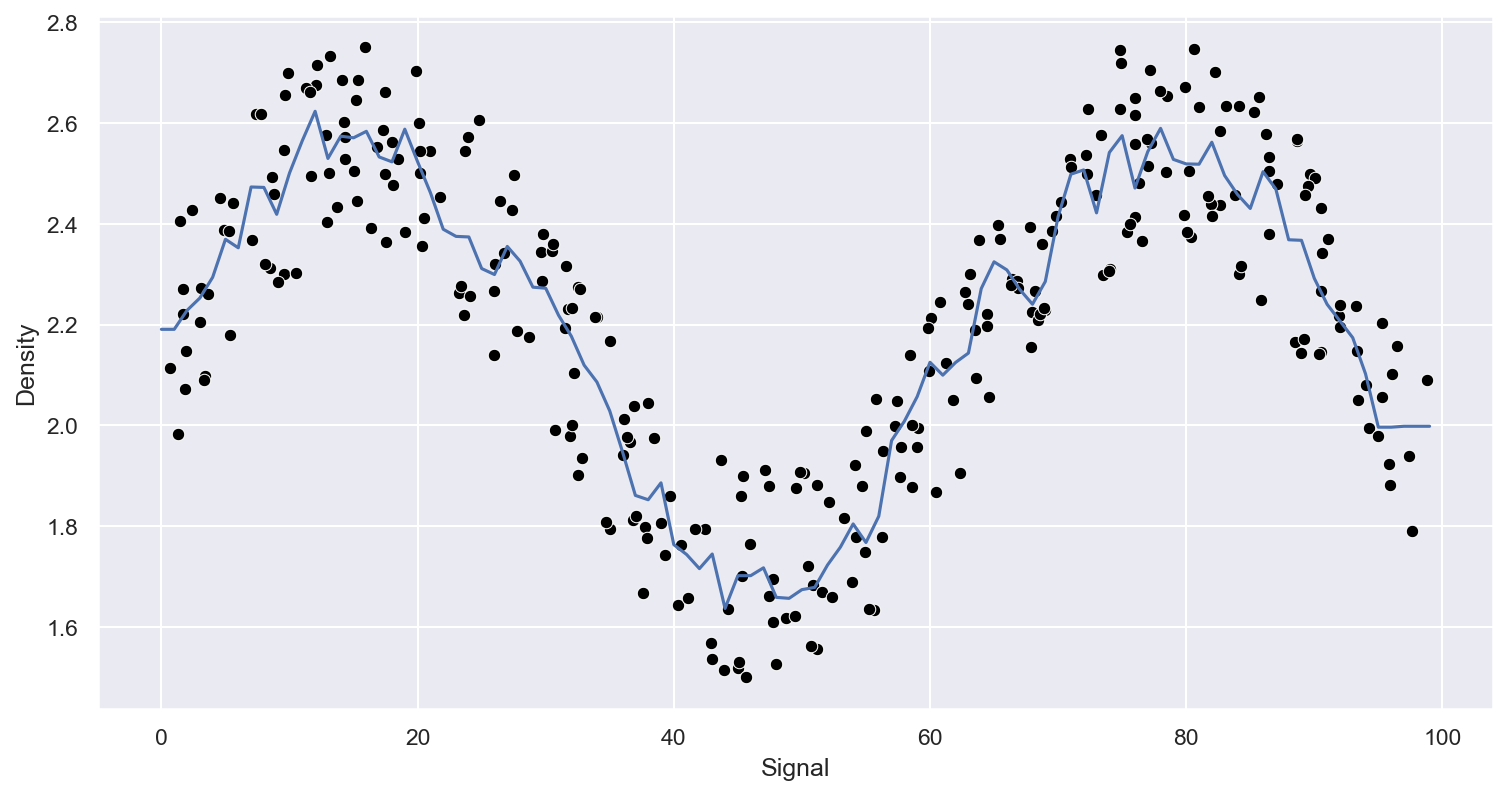

In [23]:
knn_model = KNeighborsRegressor(5)
run_model(knn_model,X_train, y_train, X_test, y_test)

In [24]:
from sklearn.svm import SVR

RMSE : 0.13672257378472114


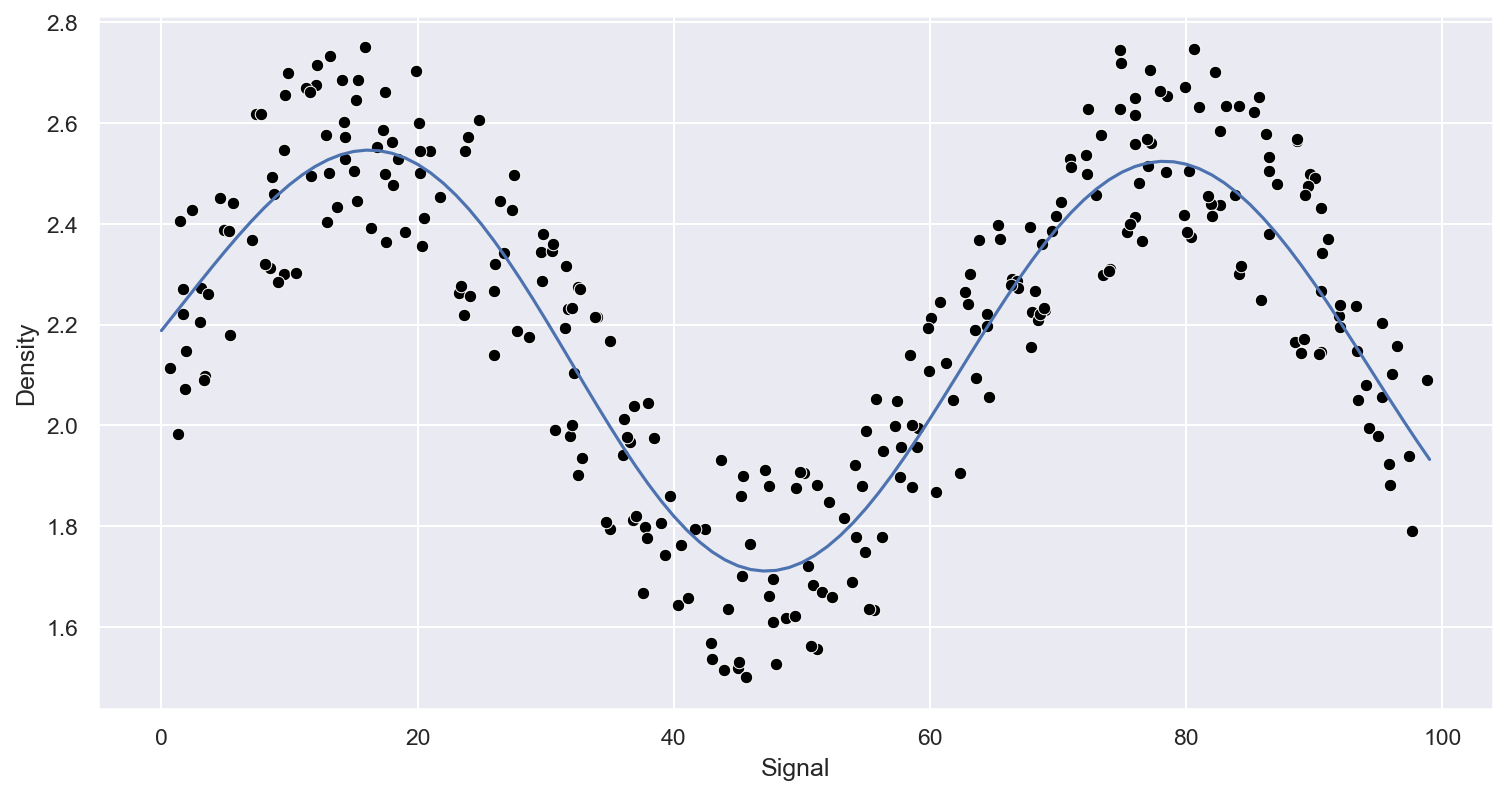

In [25]:
svr_model = SVR(C=1)
run_model(svr_model,X_train, y_train, X_test, y_test)

In [26]:
grid.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'ada__n_estimators': [1, 20, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [27]:
grid.best_params_

{'ada__n_estimators': 40}

gradient

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

In [29]:
gb_model = GradientBoostingRegressor(learning_rate=0.2)

In [30]:
gb_model.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.2
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [31]:
y_pred_gb = gb_model.predict(X_test)

In [32]:
mean_absolute_error(y_test,y_pred_gb)

0.13293279951179965

In [33]:
mean_squared_error(y_test, y_pred_gb)

0.02567023796495292

In [34]:
pipeline_gb = Pipeline([
    ('gb', GradientBoostingRegressor())])

In [35]:
param_grid_gb = {'gb__learning_rate':[0.00,0.02,0.1,1]}

In [36]:
grid_gb = GridSearchCV(pipeline_gb, param_grid_gb, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)

RMSE : 0.15065683254486653


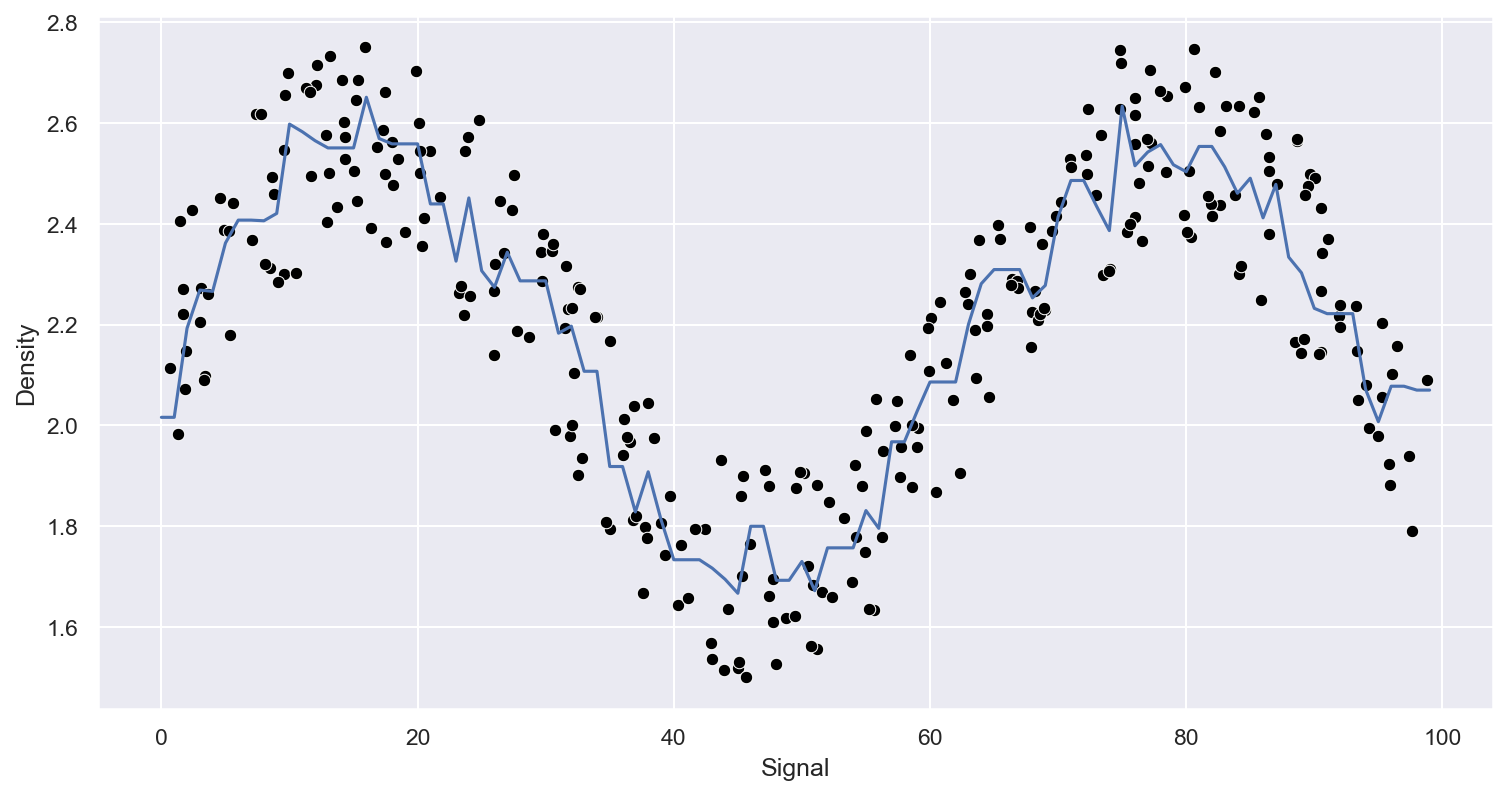

In [37]:
run_model(grid_gb,X_train, y_train, X_test, y_test)

In [38]:
grid_gb.fit(X_train,y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'gb__learning_rate': [0.0, 0.02, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [39]:
grid_gb.best_params_

{'gb__learning_rate': 0.1}

In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [46]:
tree_model = DecisionTreeRegressor(max_depth=10)

RMSE : 0.17948904220738232


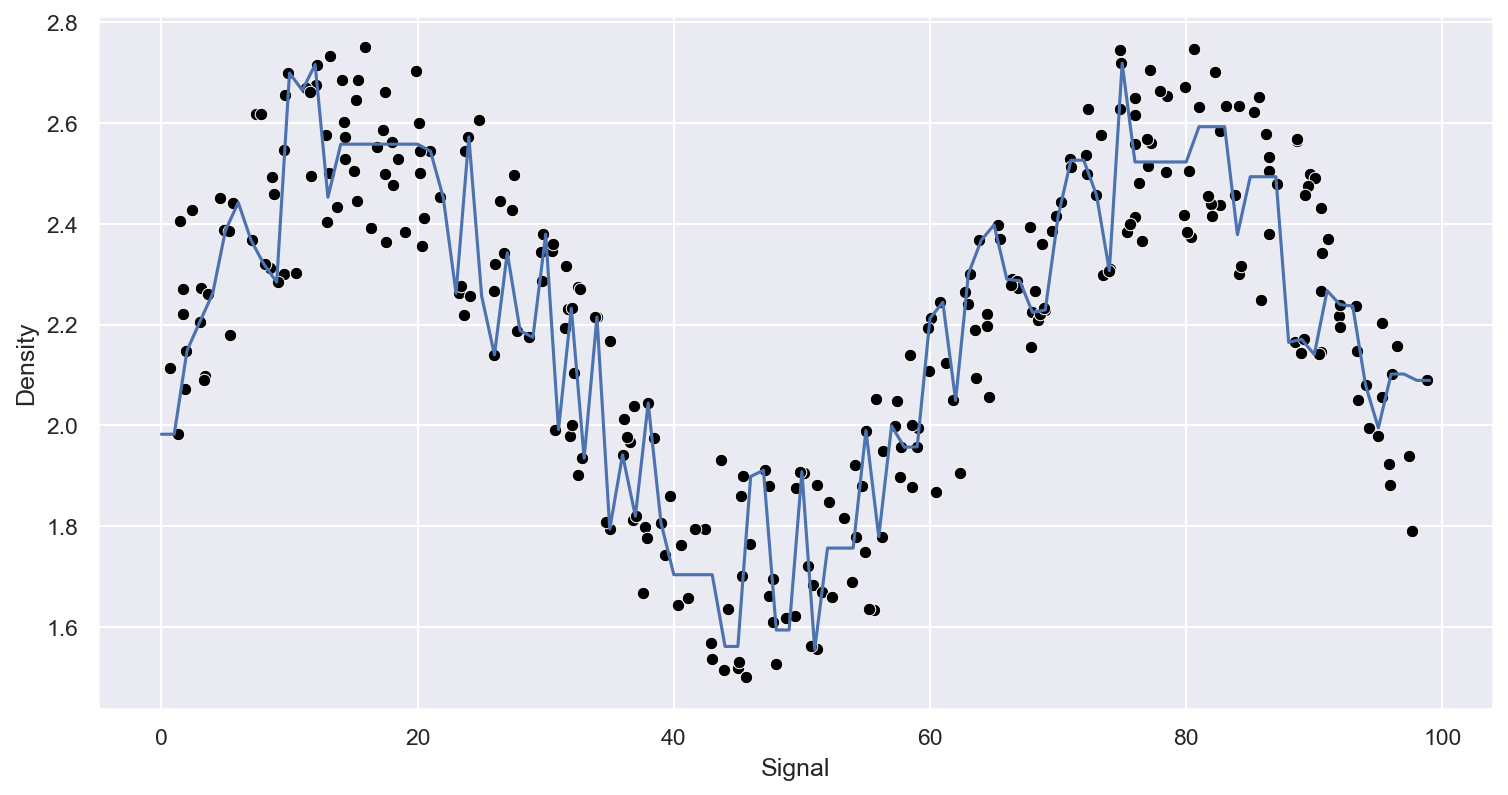

In [47]:
run_model(tree_model,X_train, y_train, X_test, y_test)

RMSE : 0.16446123682971603


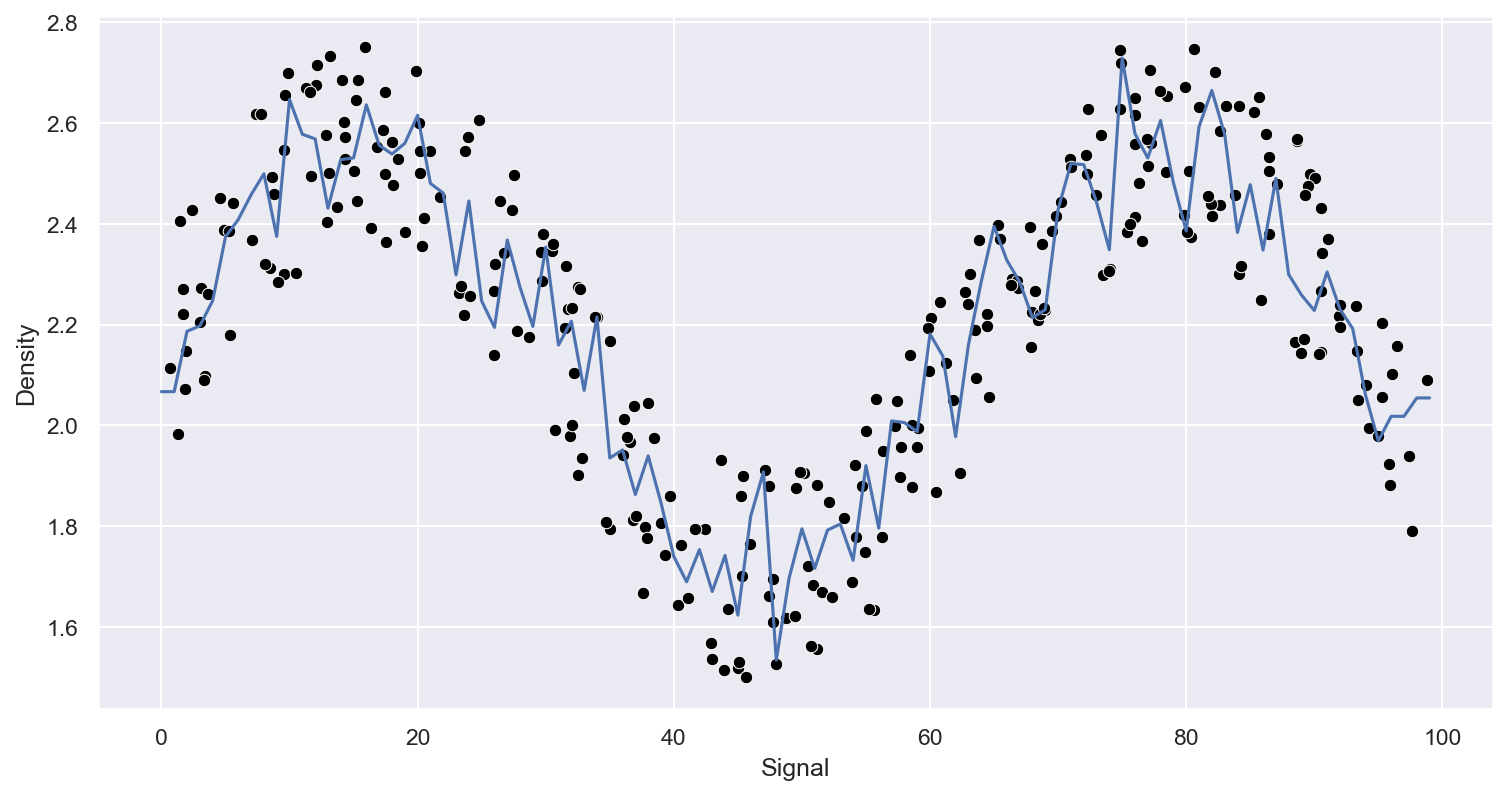

In [45]:
forest_model = RandomForestRegressor(10)
run_model(forest_model,X_train, y_train, X_test, y_test)